In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.interpolate import interp1d

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

### LCDM

In [2]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [3]:
colors = ['slateblue','tomato','darkseagreen','orchid','darkslategrey']#['b','red','g','darkorange','darkslategrey']#['orange','g','y','b','r']#['r', 'b', 'y', 'm', 'g']
masses =  [1.e-26, 1.e-25, 1.e-24, 1.e-23] # eV
masses_Mpc = [mass*1.56373846613383*1.e29 for mass in masses]# Mpc^-1

precision_settings = {
    'tol_thermo_integration': 1.0e-6,
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-7,
    'k_per_decade_primordial': 30.0,
}

lcdm = Class()
lcdm_settings = {'omega_b':omega_b,'Omega_cdm' : omega_cdm/h_planck**2,'100*theta_s': theta_s,'A_s' : As
                 ,'n_s':ns,'tau_reio':tau_reio,
                 'YHe': 'BBN','output':'tCl mPk dTk vTk','gauge':'synchronous',
                 'P_k_max_h/Mpc':100.0, 'format': 'camb', 'ic' : 'ad','P_k_ini type' : 'analytic_Pk',
                 'z_pk': '0,10,100', 'Omega_k' : 0., 'N_ncdm' : 0}
lcdm.set(lcdm_settings)

lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
background_lcdm = lcdm.get_background()

frac = 1-1.e-6
common_settings  = {
            '100*theta_s': theta_s,
            'omega_b' : omega_b,
            'Omega_cdm' : (1-frac)*omega_cdm/h_planck**2,
            'Omega_dcdmdr' : 0.0,
            'N_ncdm' : 0,
            'Omega_k' : 0.,
            'Omega_fld' : 0.,
            'Omega_scf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_scf' : 'yes',
            'scf_tuning_index' : 3,
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl,pCl,lCl,mPk',
            'P_k_max_h/Mpc' : 100.,
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'P_k_ini type' : 'analytic_Pk',
            'A_s' : As,
            'n_s' : ns,
            'l_max_scalars' : 2500,
            'P_k_max_h/Mpc' : 100.,
            'z_pk': '0,10,100',
            'format': 'camb',
            } 

common_settings.update(precision_settings) 

As a benchmark, let's define the LCDM cosmology.

In [4]:
def Pk_z0(z0, mass, kk):

    #mass_Mpc = mass*1.56373846613383*1.e29

    cosmo_angles = Class()
    cosmo_angles.set(common_settings)
    cosmo_angles.set({'P_k_max_h/Mpc' : max(kk)})
    cosmo_angles.set({'scf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles.compute()

    Pk = [] # P(k) in (Mpc/h)**3
    
    background = cosmo_angles.get_background()
    background_z = background['z']
    background_a = 1/(1+background_z)
    # K_J

    background_H_over_m = background['H [1/Mpc]']/(mass * 1.56 * 1.e29) # read k/aH = k(1+z)/H
    a_osc = interp1d(background_H_over_m, background_a)(1.)
    H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

    kj =  a_osc * np.sqrt(mass * 1.56 * 1.e29 * H_osc)/h_planck

    Pk_lcdm = [] # P(k) in (Mpc/h)**3

    for k in kk:
        Pk_lcdm.append(lcdm.pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
        Pk.append(cosmo_angles.pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
    
    data = np.column_stack((kk, Pk))
    np.savetxt('../../SFDM_data/Pk_SFDM/Pk_SFDM_m=%s_z=%s'% (str(mass)[-3:],str(z0)), data) # P(k) in (Mpc/h)**3
    
    plt.figure()
    plt.loglog(kk, Pk, 'g', label=r'SFDM', lw=3)
    plt.loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
    plt.legend(loc='lower left',fontsize=14)
    plt.ylim([min(Pk), max(Pk_lcdm)])
    plt.xlim([kk[0], kk[-1]])
    plt.vlines(kj/h_planck, 1.e-9, max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    plt.xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    plt.ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    plt.ylabel(r'Percentage diff. (%)', size=14)
    plt.title('$m = 10^{%s}$eV  -  z=%s'%(str(mass)[-3:],z0))
    plt.grid()
        
    
    plt.tight_layout()
    #plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()


### $m = 10^{-22} eV$

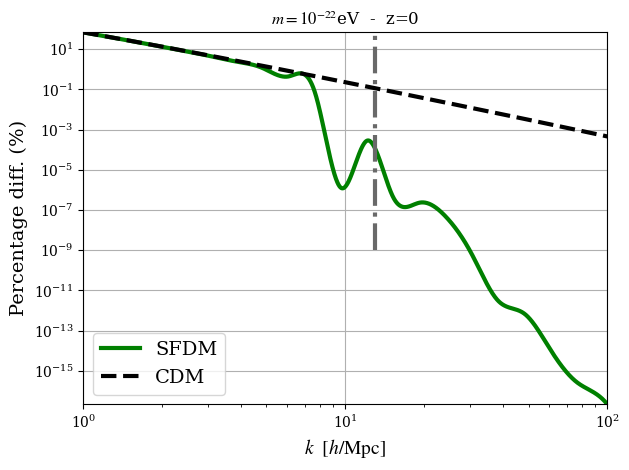

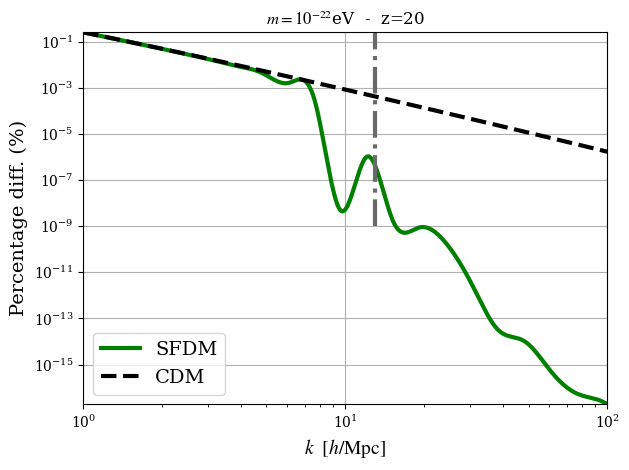

In [5]:
Pk_z0(0, 1.e-22, np.logspace(0, np.log10(100),5000))
Pk_z0(20, 1.e-22, np.logspace(0, np.log10(100),5000))

### $m = 10^{-23} eV$

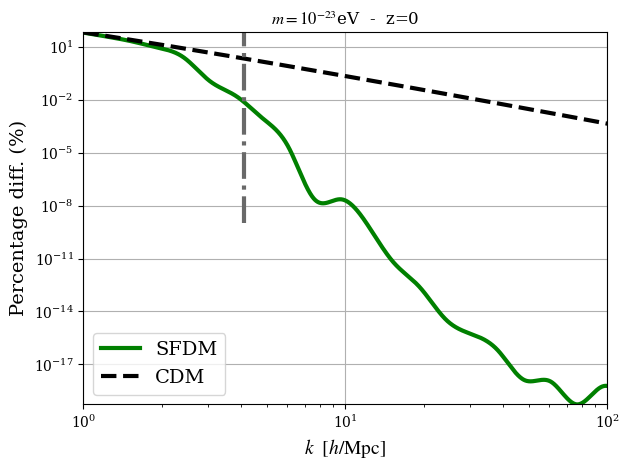

In [6]:
Pk_z0(0, 1.e-23, np.logspace(0, np.log10(100),5000))

### $m = 10^{-24} eV$

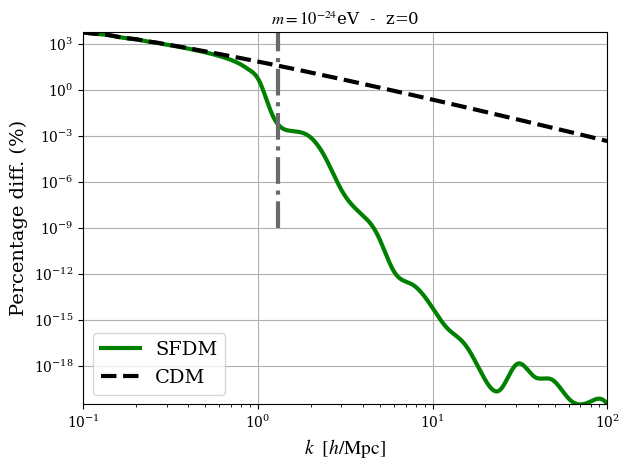

In [7]:
Pk_z0(0, 1.e-24, np.logspace(-1, np.log10(100),5000))

### $m = 10^{-25} eV$

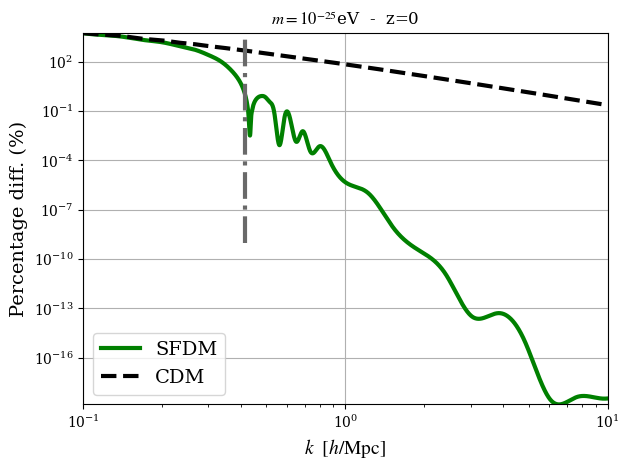

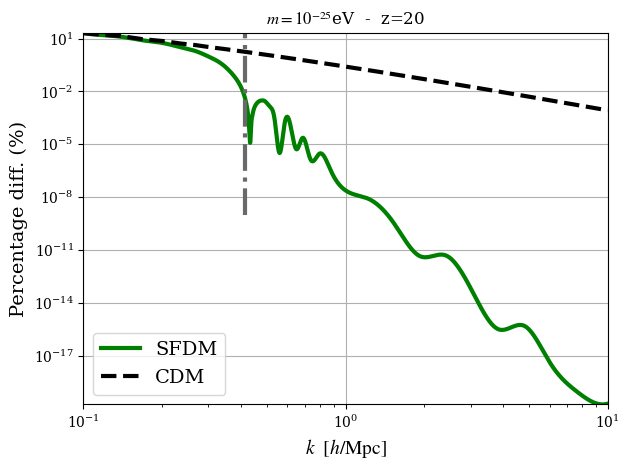

In [8]:
Pk_z0(0, 1.e-25, np.logspace(-1, np.log10(10),5000))
Pk_z0(20, 1.e-25, np.logspace(-1, np.log10(10),5000))